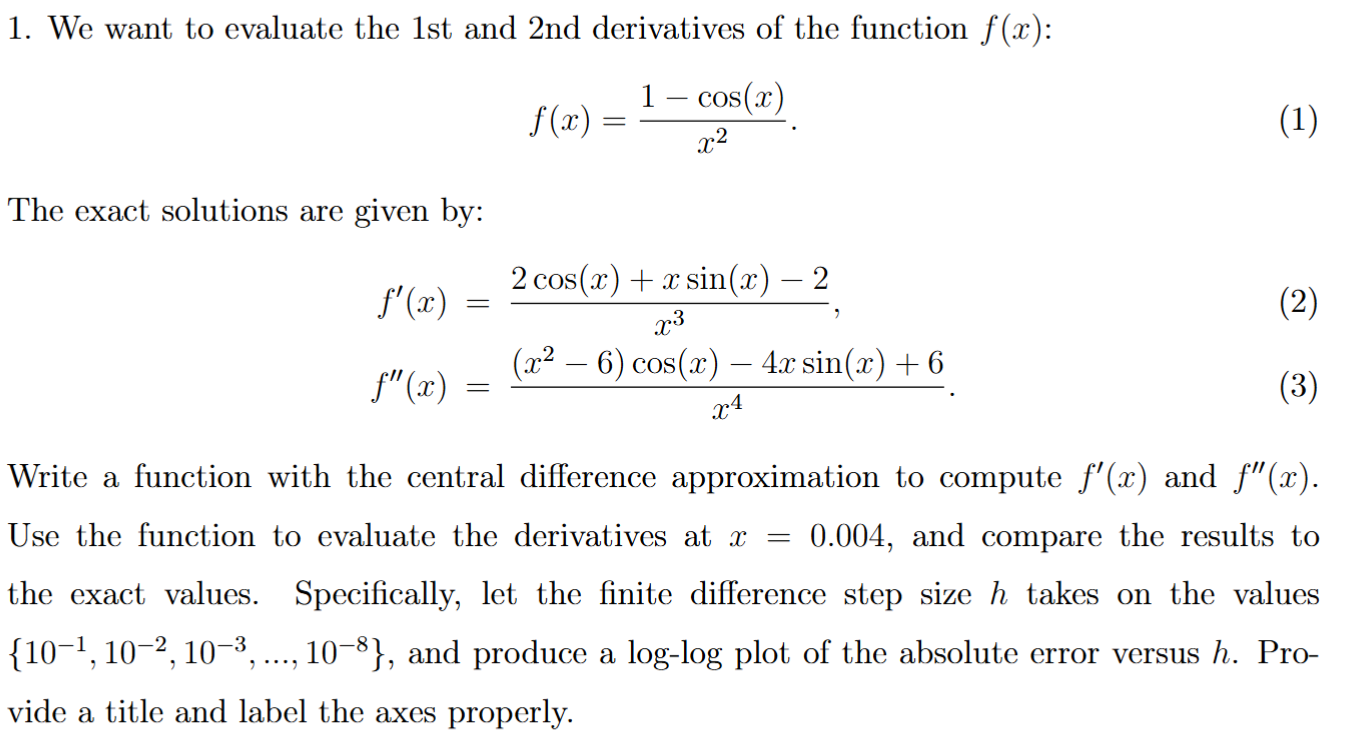

In [1]:
import numpy as np
import matplotlib.pyplot as plt

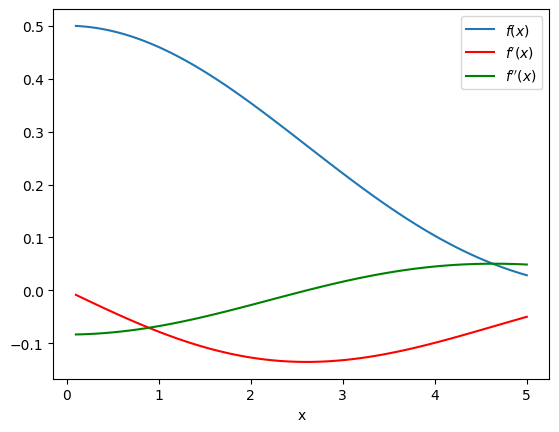

In [2]:
# Firstly, defining the function & its derivatives and plotting
def f(x):
    return (1 - np.cos(x)) / x**2  # using np.cos ensures I can pass an array as an input

def fprime(x):
    return (2*np.cos(x) + x * np.sin(x) - 2) / x**3

def fprimeprime(x):
    return ((x**2 - 6) * np.cos(x) - 4*x * np.sin(x) + 6) / x**4

x = np.linspace(0.1, 5, 101)
plt.plot(x,f(x),label="$f(x)$")  
plt.plot(x,fprime(x),label="$f'(x)$",color='r')
plt.plot(x,fprimeprime(x),label="$f''(x)$",color='g')
plt.xlabel("x")
plt.legend()

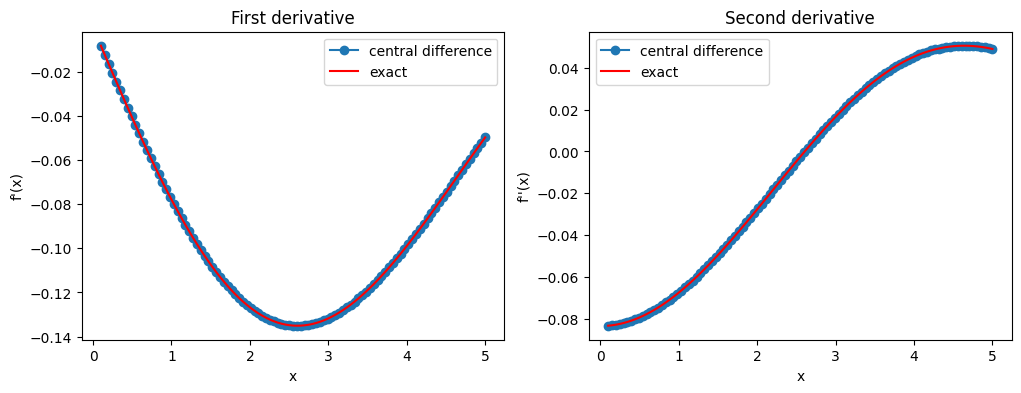

In [3]:
# defining central difference functions for the first and second derivatives
def fprime_cd(x, h):
    return (f(x+h) - f(x-h)) / (2*h)

def fprimeprime_cd(x, h):
    return (f(x+h) + f(x-h) - 2*f(x)) / h**2

# plot the exact derivative and the numerical derivative together
fig, axes = plt.subplots(1, 2, figsize=(12,4))

axes[0].set_title("First derivative")
axes[0].set_xlabel("x")
axes[0].set_ylabel("f'(x)")
axes[0].plot(x,fprime_cd(x, 0.001),marker='o',label='central difference')
axes[0].plot(x,fprime(x),color='r',label='exact')
axes[0].legend()

axes[1].set_title("Second derivative")
axes[1].set_xlabel("x")
axes[1].set_ylabel("f''(x)")
axes[1].plot(x,fprimeprime_cd(x, 0.001),marker='o',label='central difference')
axes[1].plot(x,fprimeprime(x),color='r',label='exact')
axes[1].legend()

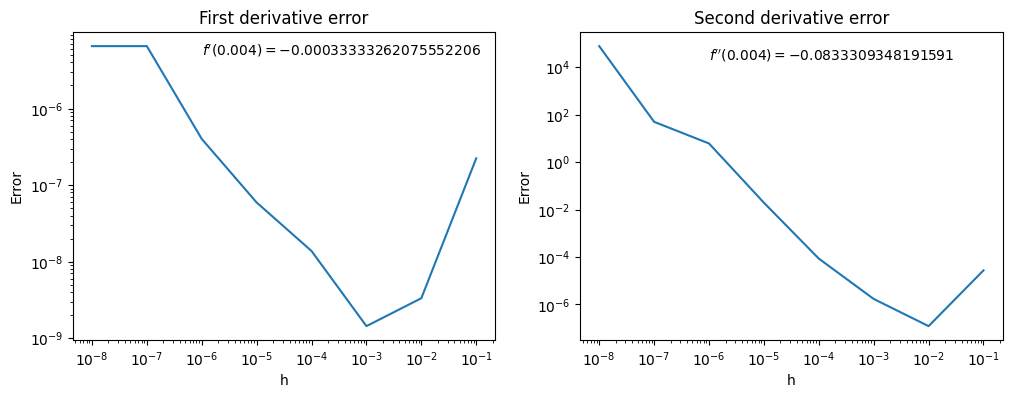

In [4]:
# compute error for each derivative and plot
h_vals = [1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6, 1e-7, 1e-8]
fprime_errors = []
fprimeprime_errors = []

for hval in h_vals:
    error1 = np.abs(fprime_cd(0.004, hval) - fprime(0.004))
    error2 = np.abs(fprimeprime_cd(0.004, hval) - fprimeprime(0.004))
    fprime_errors.append(error1)
    fprimeprime_errors.append(error2)

fig, axes = plt.subplots(1, 2, figsize=(12,4))

axes[0].set_title("First derivative error")
axes[0].set_xlabel("h")
axes[0].set_ylabel("Error")
axes[0].text(1e-6,5e-6,f"$f'(0.004)={fprime_cd(0.004,0.001)}$")
axes[0].loglog(h_vals,fprime_errors)

axes[1].set_title("Second derivative error")
axes[1].set_xlabel("h")
axes[1].set_ylabel("Error")
axes[1].text(1e-6,2e4,f"$f''(0.004)={fprimeprime_cd(0.004,0.001)}$")
axes[1].loglog(h_vals,fprimeprime_errors)

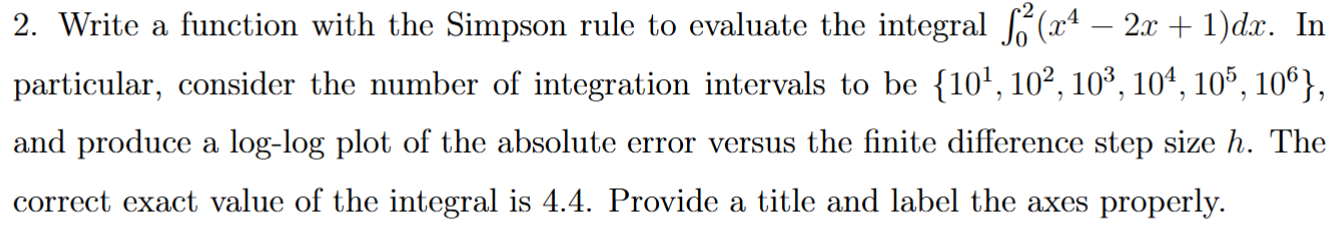

In [5]:
# Define function for Simpson's rule
def Simpson(f, a, b, n):
    if n % 2 == 0:
        print('Error: n must be an odd number!')
    else:
        h = (b-a)/(n-1)
        x = np.linspace(a,b,n)

        # Create array of c_i
        c = np.ones(n)
        for i in range(len(c)):
            if i % 2 == 0:
                c[i] = 2
            else:
                c[i] = 4
        c[0], c[-1] = 1, 1

        contribution = (h/3)*c*f(x)
        return np.sum(contribution), h

In [6]:
def func(x):
    return x**4 - 2*x + 1

I_simpson, h = Simpson(func, 0, 2, 10001)
print(f"The integral = {I_simpson}, h = {h}, h^4 = {h**4}")

The integral = 4.400000000000001, h = 0.0002, h^4 = 1.6000000000000004e-15


In [7]:
n_vals = [11, 101, 1001, 10001, 100001, 10000001]
h_vals = []
errors = []

for n in n_vals:
    I_simpson, h = Simpson(func, 0, 2, n)
    error = abs(4.4 - I_simpson)
    h_vals.append(h)
    errors.append(error)

Text(0, 0.5, 'Error')

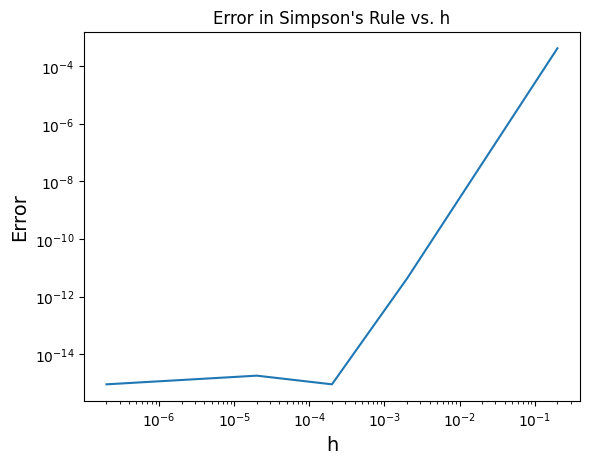

In [8]:
plt.loglog(h_vals, errors)
plt.title("Error in Simpson's Rule vs. h")
plt.xlabel("h", fontsize=14)
plt.ylabel("Error", fontsize=14)

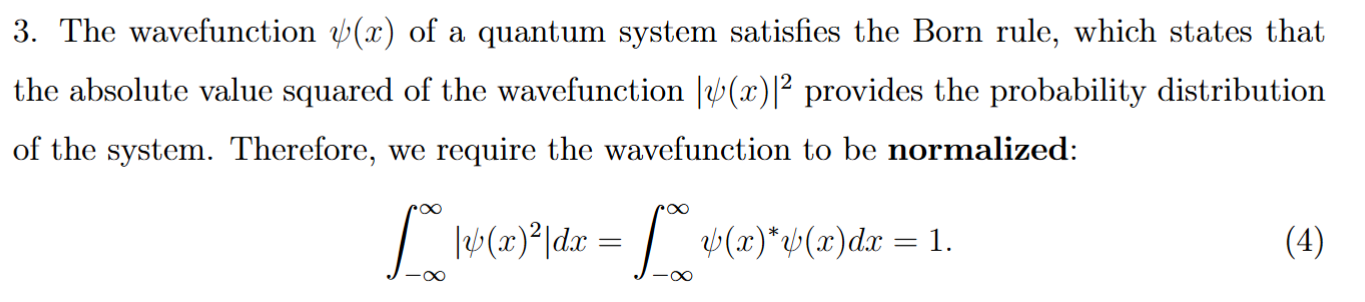
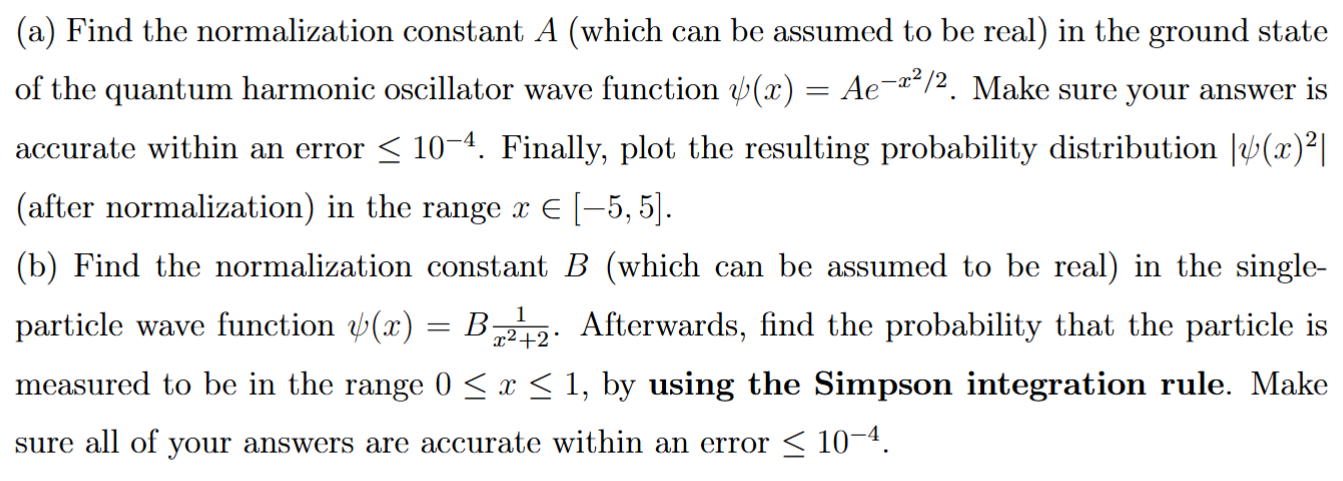

## a)
To normalize $\psi (x) = A e^{-x^2 / 2}$, need to solve for $A$. Inputting into the normaliztion equation:
\begin{equation}
    A^2 \int e^{-x^2} dx = 1
\end{equation}
So $A$ equals the square root of one over the result of the integral.

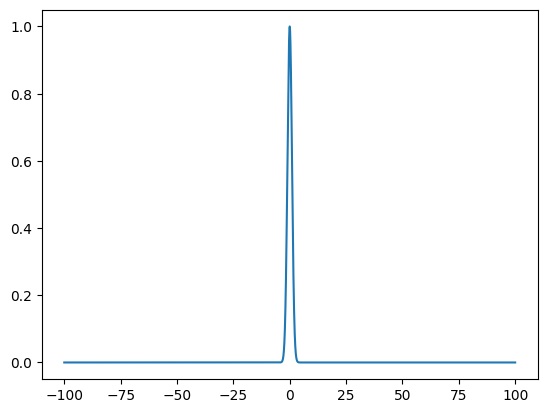

In [9]:
def psi(x):
    return np.exp(-x**2 / 2) # not normalized

# plotting the function to know what the bounds of integration should be
x = np.linspace(-100, 100, 10001)
plt.plot(x, psi(x))

A = 0.7511255444649425; h = 0.002, h^4 = 1.6000000000000003e-11


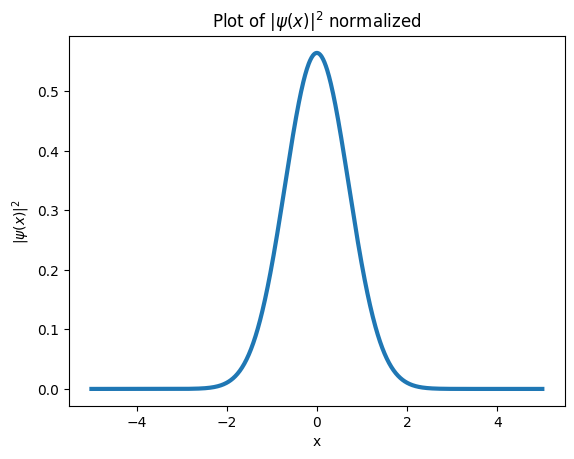

In [11]:
# Calculate the integral then find A
def psi_squared(x):
    return np.exp(-x**2)
    
psi_int, h = Simpson(psi_squared, -100, 100, 100001) # using n = 100,001 should ensure a very high accuracy
A = np.sqrt(1 / psi_int)
print(f"A = {A}; h = {h}, h^4 = {h**4}")

# plot psi(x) with the normalization constant
x = np.linspace(-5, 5, 1001)
prob_dist = (A * psi(x)) ** 2

plt.plot(x, prob_dist, lw=3)
plt.xlabel("x")
plt.ylabel(r"$|\psi(x)|^2$")
plt.title(r"Plot of $|\psi(x)|^2$ normalized")
plt.show()

## b)
Once again, to solve for B, input $\psi(x)$ into the normalization equation:
\begin{equation}
    B^2 \int \frac{1}{(x^2+2)^2} dx = 1
\end{equation}
Then, to find the probability that a particle is between 0 and 1, integrate the square of the wave function over the interval [0,1]:
\begin{equation}
    \int_{0}^{1} |\psi(x)|^2 dx = \int_{0}^{1} \frac{B^2}{(x^2+2)^2} dx
\end{equation}

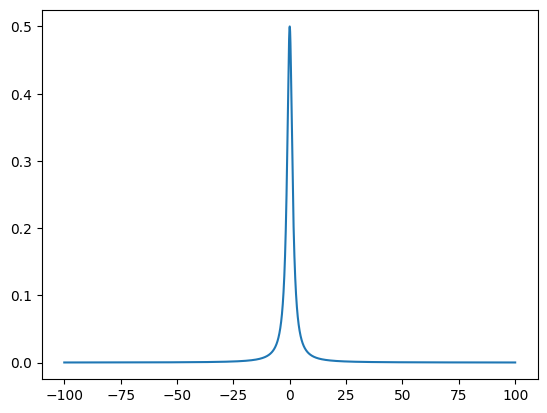

In [12]:
def psi_B(x):
    return 1 / (x**2 + 2)

# plotting the function to know what the bounds of integration should be
x = np.linspace(-100, 100, 10001)
plt.plot(x, psi_B(x))

In [13]:
# Again, calculate the integral from -100 to 100 then solve for B
def psi_B_squared(x):
    return (1 / (x**2 + 2)) ** 2

psi_B_int, h = Simpson(psi_B, -100, 100, 100001)
B = np.sqrt(1 / psi_B_int)
print(f"B = {B}; h = {h}, h^4 = {h**4}")

B = 0.6739788945344211; h = 0.002, h^4 = 1.6000000000000003e-11


In [14]:
# to find the probability a particle is between 0 and 1, integrate the square of the wave function over [0,1]
def psi_B_probamp(x):
    return (B * (1 / (x**2 + 2))) ** 2

probability, h = Simpson(psi_B_probamp, 0, 1, 1001)
print(f"The probability of finding a particle between 0 and 1 = {probability}")

The probability of finding a particle between 0 and 1 = 0.08727721749464779
